# House Price Analysis, Feature Engineering, and Price Prediction Using Machine Learning

# # Developed by DEEPAK.M AI Generalist iPEC Solutions Private Limited Bangalore


# Random Forest

# 1.Load Dataset

In [1]:
import pandas as pd
df=pd.read_csv('data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


# 2.Basic Information

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


# 3.Check Missing Values

In [3]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

## Remove less useful text columns:

In [4]:
df.drop(
    columns=['street', 'country'],
    inplace=True
)

## Separate Features and Target

In [5]:
X = df.drop('price', axis=1)
y = df['price']

# 4.Exploratory Data Analysis (EDA)

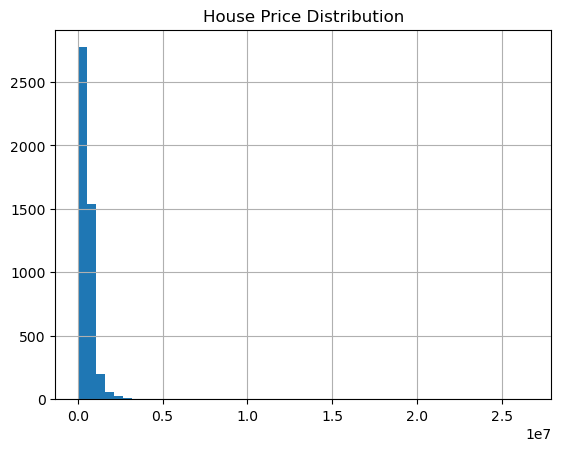

In [6]:
import matplotlib.pyplot as plt
df['price'].hist(bins=50)
plt.title("House Price Distribution")
plt.show()

## Correlation

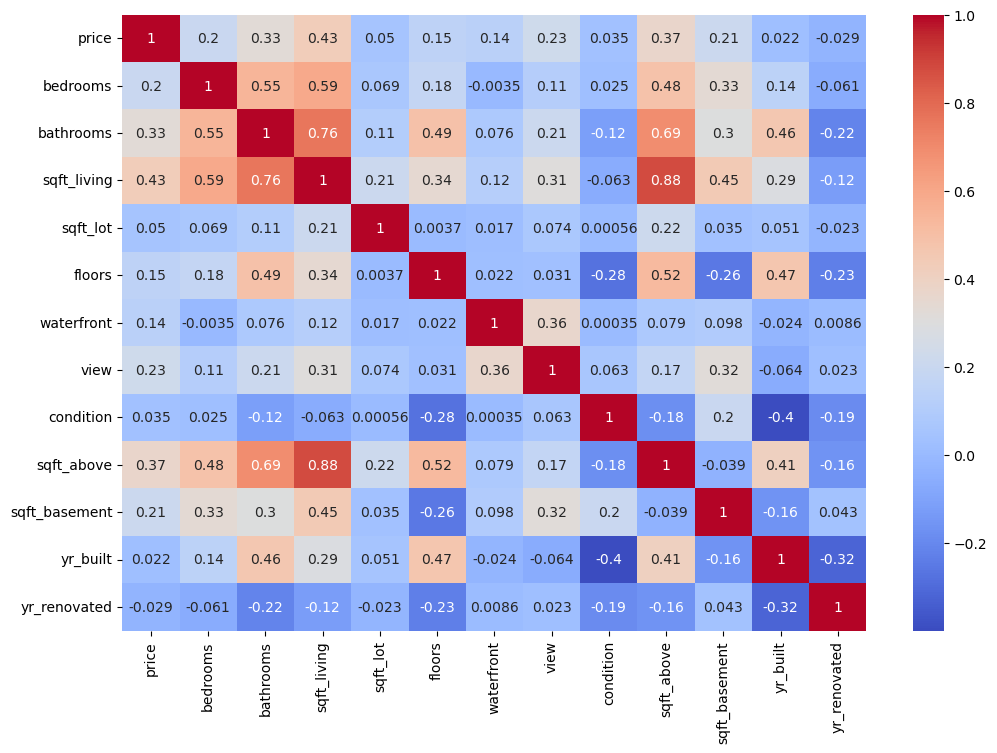

In [7]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

# 5.Insights

## Most Expensive Houses

In [8]:
df.sort_values("price", ascending=False)[
    ["price","city","bedrooms","bathrooms"]
].head(10)

,price,city,bedrooms,bathrooms
4350,26590000.0,Kent,3.0,2.00
4346,12899000.0,Seattle,3.0,2.50
2286,7062500.0,Bellevue,5.0,4.50
2654,4668000.0,Mercer Island,5.0,6.75
2761,4489000.0,Bellevue,4.0,3.00
3729,3800000.0,Clyde Hill,5.0,5.50
1637,3710000.0,Medina,4.0,3.50
252,3200000.0,Seattle,7.0,4.50
1567,3100000.0,Mercer Island,6.0,4.25
2772,3000000.0,Kirkland,4.0,4.25


## Average Price by City

In [9]:
df.groupby("city")["price"].mean().sort_values(
    ascending=False
).head(10)

city
Medina                2.046559e+06
Clyde Hill            1.321945e+06
Yarrow Point          1.194838e+06
Mercer Island         1.123818e+06
Bellevue              8.471807e+05
Beaux Arts Village    7.450000e+05
Fall City             6.926818e+05
Sammamish             6.869176e+05
Redmond               6.676495e+05
Newcastle             6.660467e+05
Name: price, dtype: float64

# 6.Feature Engineering

## Create House Age

In [10]:
df["house_age"] = 2026 - df["yr_built"]

## Convert Date

In [11]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

## Encode Categorical Columns

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["city","statezip"]:
    X[col] = le.fit_transform(X[col])

X["date"] = pd.to_datetime(X["date"])
X["date"] = X["date"].astype("int64") // 10**9

# 7.Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

# 8.Build Prediction Model

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 9.Prediction

In [16]:
pred = model.predict(X_test)

# 10.Model Evaluation

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

R2: 0.04257576819585562
RMSE: 988142.4991953442


# 11.Feature Importance

In [18]:
import pandas as pd
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
).head()

,Feature,Importance
3,sqft_living,0.517881
14,statezip,0.086850
11,yr_built,0.068014
13,city,0.052906
9,sqft_above,0.048509


# 12.Future Price Prediction

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
X = df[['sqft_living', 'bathrooms', 'waterfront','yr_built']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
new_house = pd.DataFrame({
    'sqft_living': [2500],
    'bathrooms': [3],
    'waterfront': [0],
    'yr_built':[2020]
})
prediction = model.predict(new_house)
print("Predicted Price:", prediction[0])

Predicted Price: 454070.4
